Endten finne ut hvilke lag som kommer til å vinne de ulike kampene, eller bare finne ut hvem som vinner ligaen og hvor alle ender opp


In [195]:
import pandas as pd

# Rettet raw GitHub-URL
url = "https://raw.githubusercontent.com/Steffenulv/Footballanalyzer/main/serie_a_data_2021-2025.csv"
full_data = pd.read_csv(url)

In [196]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)

In [197]:

print(full_data.shape)
full_data.head(20)

(100, 21)


,rk,squad,mp,w,d,l,gf,ga,gd,pts,pts/mp,xg,xga,xgd,xgd/90,attendance,top_team_scorer,goalkeeper,notes,sesonger,last_5
0,1,Milan,38,26,8,4,69,31,38,86,2.26,59.7,35.9,23.8,0.63,44015,"Olivier Giroud, Rafael Leão - 11",Mike Maignan,→ Champions League via league finish,2021,NaN
1,2,Inter,38,25,9,4,84,32,52,84,2.21,81.6,39.1,42.5,1.12,44473,Lautaro Martínez - 21,Samir Handanović,→ Champions League via league finish,2021,NaN
2,3,Napoli,38,24,7,7,74,31,43,79,2.08,57.8,32.5,25.3,0.67,28119,Victor Osimhen - 14,David Ospina,→ Champions League via league finish,2021,NaN
3,4,Juventus,38,20,10,8,57,37,20,70,1.84,51.4,38.1,13.4,0.35,22621,Paulo Dybala - 10,Wojciech Szczęsny,→ Champions League via league finish,2021,NaN
4,5,Lazio,38,18,10,10,77,58,19,64,1.68,55.3,47.7,7.6,0.20,23263,Ciro Immobile - 27,Thomas Strakosha,→ Europa League via league finish,2021,NaN
5,6,Roma,38,18,9,11,59,43,16,63,1.66,65.1,38.4,26.8,0.70,41929,Tammy Abraham - 17,Rui Patrício,→ Europa League via league finish,2021,NaN
6,7,Fiorentina,38,19,5,14,59,51,8,62,1.63,60.0,40.6,19.4,0.51,21107,Dušan Vlahović - 17,Pietro Terracciano,→ Europa Conference League via league finish,2021,NaN
7,8,Atalanta,38,16,11,11,65,48,17,59,1.55,62.4,45.3,17.2,0.45,10447,Mario Pašalić - 13,Juan Musso,NaN,2021,NaN
8,9,Hellas Verona,38,14,11,13,65,59,6,53,1.39,50.4,49.0,1.4,0.04,13894,Giovanni Simeone - 17,Lorenzo Montipò,NaN,2021,NaN
9,10,Torino,38,13,11,14,46,41,5,50,1.32,48.7,38.9,9.8,0.26,9846,Andrea Belotti - 8,Vanja Milinković-Savić,NaN,2021,NaN


## Data utforsking 



In [198]:
full_data['squad'].value_counts()

squad
Milan            5
Napoli           5
Juventus         5
Lazio            5
Roma             5
Fiorentina       5
Atalanta         5
Hellas Verona    5
Torino           5
Udinese          5
Bologna          5
Inter            5
Cagliari         4
Lecce            4
Genoa            4
Empoli           4
Sassuolo         4
Salernitana      3
Monza            3
Spezia           2
Sampdoria        2
Venezia          2
Cremonese        2
Como             2
Parma            2
Frosinone        1
Pisa             1
Name: count, dtype: int64

In [199]:
full_data['squad'].groupby(full_data['rk']).value_counts().head(10)

rk  squad   
1   Napoli      3
    Inter       1
    Milan       1
2   Inter       2
    Lazio       1
    Milan       1
    Roma        1
3   Atalanta    1
    Inter       1
    Juventus    1
Name: count, dtype: int64

In [200]:
import plotly.express as px

rankings = full_data['squad'].groupby(full_data['rk']).value_counts().reset_index(name='counts')

rankings = rankings[rankings['rk'].isin([1,2,3])]

figur = px.bar(rankings, x='squad', y='counts', color='rk', barmode='group', title='Antall ganger lag har endt på 1., 2. eller 3.', 
                labels={'squad': 'Lag', 'counts': 'Antall ganger', 'rk': 'Plassering'}) 

figur.update_layout(xaxis = {'categoryorder':'total descending'})
figur.show()

In [201]:
full_data.describe()

,rk,mp,w,d,l,gf,ga,gd,pts,pts/mp,xg,xga,xgd,xgd/90,attendance,sesonger
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,10.500000,32.000000,11.540000,8.920000,11.540000,42.100000,42.100000,0.000000,43.440000,1.352900,40.264000,40.271000,0.00100,0.000100,28008.800000,2023.000000
std,5.795331,12.060454,7.392899,4.076739,6.797831,21.619529,20.445789,23.195262,23.234562,0.496359,18.457565,18.134767,17.90373,0.516579,18691.502842,1.421338
min,1.000000,8.000000,0.000000,0.000000,0.000000,3.000000,3.000000,-49.000000,3.000000,0.380000,5.500000,6.800000,-44.10000,-1.160000,6356.000000,2021.000000
25%,5.750000,38.000000,6.000000,6.000000,4.750000,30.500000,31.000000,-14.250000,27.750000,0.950000,34.475000,32.450000,-12.77500,-0.425000,13902.250000,2022.000000
50%,10.500000,38.000000,10.000000,9.000000,12.000000,43.500000,46.000000,-0.500000,43.500000,1.375000,42.250000,41.900000,0.55000,0.025000,21862.500000,2023.000000
75%,15.250000,38.000000,18.000000,12.000000,17.000000,59.000000,58.000000,16.250000,63.000000,1.687500,52.925000,53.000000,12.22500,0.432500,38675.250000,2024.000000
max,20.000000,38.000000,29.000000,19.000000,26.000000,89.000000,81.000000,67.000000,94.000000,2.470000,81.600000,74.400000,47.10000,1.240000,72838.000000,2025.000000


In [202]:
vinnende_lag = full_data[full_data['rk'] == 1][["sesonger", "squad", "pts", "pts/mp", "gd"]].sort_values("sesonger")

print(vinnende_lag)

    sesonger   squad  pts  pts/mp  gd
0       2021   Milan   86    2.26  38
20      2022  Napoli   90    2.37  49
40      2023   Inter   94    2.47  67
60      2024  Napoli   82    2.16  32
80      2025  Napoli   18    2.25   7


In [203]:
vinnende_lag_siste_5 = full_data[(full_data['rk'] ==1) & (full_data["sesonger"] < 2025)]

snitt_pts_mp_vinnere = vinnende_lag_siste_5["pts/mp"].mean()

print(f"🏆 Snitt poeng per kamp for serievinnerne de siste 5 sesongene: {snitt_pts_mp_vinnere:.2f} pts/mp")

🏆 Snitt poeng per kamp for serievinnerne de siste 5 sesongene: 2.31 pts/mp


In [204]:
full_data["er_vinner"] = (full_data["rk"] == 1).astype(int)

kunn_vinnere = full_data[full_data["er_vinner"] == 1]

In [205]:
full_data.head(2)

,rk,squad,mp,w,d,l,gf,ga,gd,pts,pts/mp,xg,xga,xgd,xgd/90,attendance,top_team_scorer,goalkeeper,notes,sesonger,last_5,er_vinner
0,1,Milan,38,26,8,4,69,31,38,86,2.26,59.7,35.9,23.8,0.63,44015,"Olivier Giroud, Rafael Leão - 11",Mike Maignan,→ Champions League via league finish,2021,NaN,1
1,2,Inter,38,25,9,4,84,32,52,84,2.21,81.6,39.1,42.5,1.12,44473,Lautaro Martínez - 21,Samir Handanović,→ Champions League via league finish,2021,NaN,0


In [206]:
mean_pts_pm = kunn_vinnere["pts/mp"].mean()

print(f"Mean av 'pts/mp': {mean_pts_pm:.2f}")


Mean av 'pts/mp': 2.30


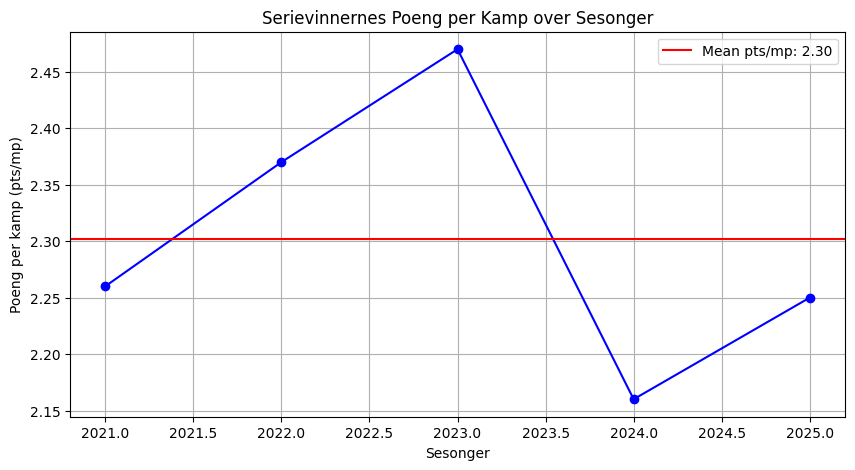

In [207]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(kunn_vinnere["sesonger"], kunn_vinnere["pts/mp"], marker='o', linestyle='-', color='b')
plt.axhline(y=mean_pts_pm, color='r', linestyle='-', label=f'Mean pts/mp: {mean_pts_pm:.2f}')
plt.xlabel('Sesonger')
plt.ylabel('Poeng per kamp (pts/mp)')
plt.title('Serievinnernes Poeng per Kamp over Sesonger')
plt.grid(True)
plt.legend()
plt.show()

In [208]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, log_loss
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np


In [209]:
full_data["kamper_igjen"] = 38 - full_data["mp"]

full_data["forventet_pts"] = full_data["pts"] + (full_data["pts/mp"] * full_data["kamper_igjen"])

full_data["er_vinner"] = (full_data["rk"] == 1).astype(int)


In [210]:
# Lag season-baserte rolling-features per lag (bruk kun tidligere sesonger for å unngå lekkasje)
full_data = full_data.sort_values(['squad', 'sesonger'])

# Shift så vi kun bruker tidligere sesongers verdier for hver rad
full_data['pts_mp_prev1'] = full_data.groupby('squad')['pts/mp'].shift(1)
full_data['pts_mp_prev2'] = full_data.groupby('squad')['pts/mp'].shift(2)
full_data['pts_mp_prev3'] = full_data.groupby('squad')['pts/mp'].shift(3)
full_data['pts_mp_last3_mean'] = full_data[['pts_mp_prev1', 'pts_mp_prev2', 'pts_mp_prev3']].mean(axis=1)

full_data['gd_prev1'] = full_data.groupby('squad')['gd'].shift(1)
full_data['gd_prev2'] = full_data.groupby('squad')['gd'].shift(2)
full_data['gd_prev3'] = full_data.groupby('squad')['gd'].shift(3)
full_data['gd_last3_mean'] = full_data[['gd_prev1', 'gd_prev2', 'gd_prev3']].mean(axis=1)

# Enkel trend (endring fra siste til nest siste sesong)
full_data['pts_mp_trend'] = full_data['pts_mp_prev1'] - full_data['pts_mp_prev2']

# Hvor mange tidligere sesonger finnes for laget (0 betyr ingen tidligere sesong)
full_data['seasons_played'] = full_data.groupby('squad').cumcount()

print('Lagt til rolling-season features: pts_mp_last3_mean, gd_last3_mean, pts_mp_prev*, pts_mp_trend, seasons_played')


Lagt til rolling-season features: pts_mp_last3_mean, gd_last3_mean, pts_mp_prev*, pts_mp_trend, seasons_played


In [211]:
full_data.tail(3)

,rk,squad,mp,w,d,l,gf,ga,gd,pts,pts/mp,xg,xga,xgd,xgd/90,attendance,top_team_scorer,goalkeeper,notes,sesonger,last_5,er_vinner,kamper_igjen,forventet_pts,pts_mp_prev1,pts_mp_prev2,pts_mp_prev3,pts_mp_last3_mean,gd_prev1,gd_prev2,gd_prev3,gd_last3_mean,pts_mp_trend,seasons_played
88,9,Udinese,8,3,3,2,10,12,-2,12,1.50,9.1,7.9,1.1,0.14,21022,Keinan Davis - 3,Razvan Sava,NaN,2025,L L D D W,0,30,57.0,1.16,0.97,1.21,1.113333,-15.0,-16.0,-1.0,-10.666667,0.19,4
19,20,Venezia,38,6,9,23,34,69,-35,27,0.71,36.5,71.8,-35.3,-0.93,6648,Thomas Henry - 9,Niki Mäenpää,Relegated,2021,NaN,0,0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
78,19,Venezia,38,5,14,19,32,56,-24,29,0.76,35.8,57.5,-21.7,-0.57,10415,Joel Pohjanpalo - 6,Filip Stankovic,Relegated,2024,NaN,0,0,29.0,0.71,NaN,NaN,0.710000,-35.0,NaN,NaN,-35.000000,NaN,1


In [212]:
fetures = ["pts/mp", "gd", "w", "d", "l", "forventet_pts", "pts_mp_last3_mean", "gd_last3_mean", "pts_mp_trend", "seasons_played"]

# Split basert på sesonger
df_train = full_data[full_data["sesonger"] < 2025]

df_test = full_data[full_data["sesonger"] == 2025].copy()

X_train = df_train[fetures].fillna(0)
y_train = df_train["er_vinner"]
X_test = df_test[fetures].fillna(0)

# Sjekk klassefordeling
print("y_train value counts:\n", y_train.value_counts())


y_train value counts:
 er_vinner
0    76
1     4
Name: count, dtype: int64


In [213]:
# Fyll NaN på nytt for sikkerhet
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Bruk class_weight for å håndtere skjev target
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
model.fit(X_train, y_train)

print("Model trent ferdig.")


Model trent ferdig.


In [214]:
train_preds = model.predict(X_train)
train_probs = model.predict_proba(X_train)[:, 1]


In [215]:
accuracy = accuracy_score(y_train, train_preds)
roc_auc = roc_auc_score(y_train, train_probs)
logloss = log_loss(y_train, train_probs)

print(f"\nModel Performance på Treningsdata:")
print(f" - Nøyaktighet: {accuracy:.3f}")
print(f" - ROC AUC: {roc_auc:.3f}")
print(f" - Logg tap: {logloss:.3f}")

print("\nKlassifikasjonsrapport:")
print(classification_report(y_train, train_preds))

print("Confusion Matrix:")
print(confusion_matrix(y_train, train_preds))




Model Performance på Treningsdata:
 - Nøyaktighet: 1.000
 - ROC AUC: 1.000
 - Logg tap: 0.023

Klassifikasjonsrapport:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        76
           1       1.00      1.00      1.00         4

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

Confusion Matrix:
[[76  0]
 [ 0  4]]


* Nøyaktighet = hver gang modellen sa ja, hvor mange ganger var dette riktig
* Recall = hvor mange av de faktiske ja ene fant modellen
* F1-score = en blanding av recall og nøyaktighet
* support = anntallet tilfeller
* confusion matrix = tabell som viser hva modellen fikk rett og hva den fikk feil

In [216]:
df_test["sjanse_vinner"] = model.predict_proba(X_test)[:, 1]

In [217]:
df_test.head()

,rk,squad,mp,w,d,l,gf,ga,gd,pts,pts/mp,xg,xga,xgd,xgd/90,attendance,top_team_scorer,goalkeeper,notes,sesonger,last_5,er_vinner,kamper_igjen,forventet_pts,pts_mp_prev1,pts_mp_prev2,pts_mp_prev3,pts_mp_last3_mean,gd_prev1,gd_prev2,gd_prev3,gd_last3_mean,pts_mp_trend,seasons_played,sjanse_vinner
86,7,Atalanta,8,2,6,0,12,6,6,12,1.50,11.8,7.1,4.7,0.58,22220,"Nikola Krstović, Charles De Ketelaere... - 2",Marco Carnesecchi,NaN,2025,W D D D D,0,30,57.0,1.95,1.82,1.68,1.816667,41.0,30.0,18.0,29.666667,0.13,4,0.080
84,5,Bologna,8,4,2,2,13,7,6,14,1.75,10.4,9.3,1.1,0.14,28106,Riccardo Orsolini - 5,Łukasz Skorupski,NaN,2025,W D W W D,0,30,66.5,1.63,1.79,1.42,1.613333,10.0,22.0,4.0,12.000000,-0.16,4,0.075
93,14,Cagliari,8,2,3,3,8,10,-2,9,1.13,6.8,13.8,-7.0,-0.88,16063,"Andrea Belotti, Mattia Felici - 2",Elia Caprile,NaN,2025,W L D L D,0,30,42.9,0.95,0.95,0.79,0.896667,-16.0,-26.0,-34.0,-25.333333,0.00,3,0.065
85,6,Como,8,3,4,1,9,5,4,13,1.63,9.6,7.2,2.3,0.29,11622,Nicolás Paz - 4,Jean Butez,NaN,2025,W D D W D,0,30,61.9,1.29,NaN,NaN,1.290000,-3.0,NaN,NaN,-3.000000,NaN,1,0.075
90,11,Cremonese,8,2,5,1,9,10,-1,11,1.38,6.4,12.1,-5.7,-0.71,11440,"Federico Bonazzoli, Federico Baschirotto... - 2","Marco Silvestri, Emil Audero",NaN,2025,D D L D D,0,30,52.4,0.71,NaN,NaN,0.710000,-33.0,NaN,NaN,-33.000000,NaN,1,0.065


In [218]:
df_test["sjanse_vinner (%)"] = df_test["sjanse_vinner"] / df_test["sjanse_vinner"].sum() * 100

df_test["sjanse_vinner (%)"] = df_test["sjanse_vinner (%)"].round(3)


In [219]:
# Poisson-basert Monte Carlo-simulering for resterende kamper
import numpy as np

# Antall simuleringer
n_sims = 5000

# Velg kolonner som trengs
teams = df_test['squad'].values
remaining = df_test['kamper_igjen'].fillna(0).astype(int).values
pts_current = df_test['pts'].fillna(0).values.astype(int)

# Beregn mål-lambdas (mål per kamp) hvis data finnes, ellers estimer fra gd
if set(['g', 'ga']).issubset(df_test.columns):
    atk_lambda = (df_test['g'] / df_test['mp']).fillna(0.1).values
    def_lambda = (df_test['ga'] / df_test['mp']).fillna(0.1).values
else:
    # Fallback: estimat basert på goal difference per kamp
    league_avg_goals = 1.3  # antakelse per lag per kamp
    proxy = (df_test['gd'] / df_test['mp']).fillna(0).values
    atk_lambda = np.maximum(0.1, league_avg_goals + 0.5 * proxy)
    def_lambda = np.maximum(0.1, league_avg_goals - 0.5 * proxy)

# Integrer modellprediksjoner som en moderat styrkefaktor hvis tilgjengelig
model_probs = None
if 'model' in globals():
    try:
        model_probs = model.predict_proba(X_test.fillna(0))[:, 1]
    except Exception:
        model_probs = None
elif 'calibrator' in globals():
    try:
        model_probs = calibrator.predict_proba(X_test.fillna(0))[:, 1]
    except Exception:
        model_probs = None

if model_probs is not None:
    mean_p = np.mean(model_probs)
    # Lag en moderat multiplicative faktor (clip for å unngå ekstreme endringer)
    strength_factor = 1 + 0.5 * (model_probs - mean_p)
    strength_factor = np.clip(strength_factor, 0.5, 1.5)
    atk_lambda_adj = atk_lambda * strength_factor
else:
    atk_lambda_adj = atk_lambda

# Bruk gjennomsnittlig motstander-defense for match-simulering
mean_defense = np.mean(def_lambda)

# Run sims
wins = np.zeros(len(teams), dtype=int)
for sim in range(n_sims):
    pts = pts_current.copy().astype(int)
    # For hver lag, simuler resterende matcher mot en gjennomsnittlig motstander
    for i in range(len(teams)):
        k = int(remaining[i])
        if k <= 0:
            continue
        atk = atk_lambda_adj[i]
        for _ in range(k):
            gf = np.random.poisson(atk)
            ga = np.random.poisson(mean_defense)
            if gf > ga:
                pts[i] += 3
            elif gf == ga:
                pts[i] += 1
            # else 0
    # finn vinner(e)
    max_pts = pts.max()
    candidates = np.where(pts == max_pts)[0]
    winner = np.random.choice(candidates)
    wins[winner] += 1

# Legg til sannsynlighet i df_test
df_test['poisson_win_prob (%)'] = (wins / n_sims * 100).round(3)

print('Topp kandidater etter Poisson-simulering:')
display(df_test.sort_values('poisson_win_prob (%)', ascending=False)[['squad', 'pts', 'kamper_igjen', 'poisson_win_prob (%)']])

print(f'Kjørte {n_sims} simuleringer. Merk: dette er et forenklet estimat som antar gjennomsnittlig motstander for resterende kamper.')

Topp kandidater etter Poisson-simulering:


,squad,pts,kamper_igjen,poisson_win_prob (%)
80,Napoli,18,30,43.84
81,Roma,18,30,25.66
82,Milan,17,30,14.52
83,Inter,15,30,9.48
84,Bologna,14,30,3.34
86,Atalanta,12,30,1.50
85,Como,13,30,0.92
89,Lazio,11,30,0.54
87,Juventus,12,30,0.14
92,Sassuolo,10,30,0.04


Kjørte 5000 simuleringer. Merk: dette er et forenklet estimat som antar gjennomsnittlig motstander for resterende kamper.


In [220]:
# Kombiner modellens sannsynligheter og Poisson-simulering
# alpha = vekt for modellprediksjon (0.0 = bare Poisson, 1.0 = bare modell)
alpha = 0.6

# Sørg for at modelprediksjon finnes
if 'sjanse_vinner' not in df_test.columns:
    if 'sjanse_vinner_model' in df_test.columns:
        df_test['sjanse_vinner'] = df_test['sjanse_vinner_model']
    else:
        try:
            df_test['sjanse_vinner'] = model.predict_proba(X_test.fillna(0))[:, 1]
        except Exception:
            df_test['sjanse_vinner'] = 0

# Konverter Poisson-prosent til sannsynlighet (0-1)
df_test['poisson_prob'] = df_test.get('poisson_win_prob (%)', 0) / 100.0

# Fyll NaN
df_test['sjanse_vinner'] = df_test['sjanse_vinner'].fillna(0)
df_test['poisson_prob'] = df_test['poisson_prob'].fillna(0)

# Normaliser til sum=1 (hvis summen > 0)
sum_model = df_test['sjanse_vinner'].sum()
sum_poisson = df_test['poisson_prob'].sum()

if sum_model > 0:
    model_norm = df_test['sjanse_vinner'] / sum_model
else:
    model_norm = df_test['sjanse_vinner']

if sum_poisson > 0:
    poisson_norm = df_test['poisson_prob'] / sum_poisson
else:
    poisson_norm = df_test['poisson_prob']

# Kombinert sannsynlighet
df_test['combined_prob'] = alpha * model_norm + (1 - alpha) * poisson_norm

df_test['combined_prob (%)'] = (df_test['combined_prob'] * 100).round(3)

print(f'Viser topplag etter kombinert sannsynlighet (alpha={alpha}):')
display(df_test.sort_values('combined_prob (%)', ascending=False)[['squad', 'pts', 'kamper_igjen', 'sjanse_vinner', 'poisson_win_prob (%)', 'combined_prob (%)']])


Viser topplag etter kombinert sannsynlighet (alpha=0.6):


,squad,pts,kamper_igjen,sjanse_vinner,poisson_win_prob (%),combined_prob (%)
80,Napoli,18,30,0.520,43.84,30.536
81,Roma,18,30,0.490,25.66,22.514
82,Milan,17,30,0.220,14.52,11.308
83,Inter,15,30,0.135,9.48,7.167
84,Bologna,14,30,0.075,3.34,3.211
86,Atalanta,12,30,0.080,1.50,2.600
85,Como,13,30,0.075,0.92,2.243
89,Lazio,11,30,0.080,0.54,2.216
87,Juventus,12,30,0.085,0.14,2.181
91,Torino,11,30,0.075,0.00,1.875


In [221]:
# Eksporter kombinert sannsynlighet til JSON for nettsiden
import json, os

# Velg kolonner og gi riktig navn som nettsiden forventer
out = df_test[['squad', 'combined_prob (%)']].copy()
out = out.rename(columns={'combined_prob (%)': 'sjanse_vinner_pct'})
# Sørg for numerisk verdi og rund av
out['sjanse_vinner_pct'] = out['sjanse_vinner_pct'].round(3).astype(float)

out_list = out.to_dict(orient='records')

output_path = 'sjanse_vinner_2025.json'
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(out_list, f, ensure_ascii=False, indent=2)

print(f'Skrevet {len(out_list)} rader til {output_path}')

Skrevet 20 rader til sjanse_vinner_2025.json


In [222]:
df_test = df_test.sort_values("forventet_pts", ascending=False)
print("\n Seriemestersjanser 2025:")
df_test[["squad", "pts", "forventet_pts", "pts/mp", "gd", "kamper_igjen", "sjanse_vinner (%)"]]



 Seriemestersjanser 2025:


,squad,pts,forventet_pts,pts/mp,gd,kamper_igjen,sjanse_vinner (%)
81,Roma,18,85.5,2.25,5,30,20.417
80,Napoli,18,85.5,2.25,7,30,21.667
82,Milan,17,80.9,2.13,7,30,9.167
83,Inter,15,71.4,1.88,8,30,5.625
84,Bologna,14,66.5,1.75,6,30,3.125
85,Como,13,61.9,1.63,4,30,3.125
86,Atalanta,12,57.0,1.50,6,30,3.333
87,Juventus,12,57.0,1.50,1,30,3.542
88,Udinese,12,57.0,1.50,-2,30,2.708
90,Cremonese,11,52.4,1.38,-1,30,2.708


In [223]:
import plotly.express as px

df_test_sortert = df_test.sort_values("sjanse_vinner (%)", ascending=False) 
figur = px.bar(
    df_test_sortert, 
    x="squad", 
    y="sjanse_vinner (%)", 
    color_discrete_sequence=["blue"],
    title="Sjanse for å vinne Serie A 2025 etter modellens prediksjon",
    labels={"squad": "Lag", "sjanse_vinner (%)": "Sjanse for å vinne (%)"},
    template="plotly_white"
)

figur.update_layout(
    xaxis_title="Lag",
    yaxis_title="Sjanse for å vinne (%)",
    xaxis_tickangle=-45,
    bargap=0.3,
    title_x=0.5
    )
figur.show()
